### **Install and Import Required Libraries**

In [1]:
# Install required package
!pip install statsmodels

# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Set random seed for reproducibility
np.random.seed(42)

print("Setup Complete! Ready to simulate and analyze data.")

Setup Complete! Ready to simulate and analyze data.


### **Simulate Monthly Sales Data**

In [2]:
# Generate monthly dates for 4 years
months = pd.date_range(start='2022-01-01', periods=48, freq='ME')

# Trend Component
trend = 0.5 * np.arange(48) + 20

# Seasonal Component
seasonality = 5 * np.sin(2 * np.pi * months.month / 12)

# Random Noise
noise = np.random.normal(0, 1.5, 48)

# Total Sales
sales_values = trend + seasonality + noise

# Create DataFrame
df = pd.DataFrame({'Sales': sales_values}, index=months)

df.head(10)

,Sales
2022-01-31,23.245071
2022-02-28,24.622731
2022-03-31,26.971533
2022-04-30,28.114672
2022-05-31,24.148770
2022-06-30,22.148795
2022-07-31,22.868819
2022-08-31,20.321025
2022-09-30,18.295788
2022-10-31,20.983713


### **Exploratory Data Analysis (EDA)**

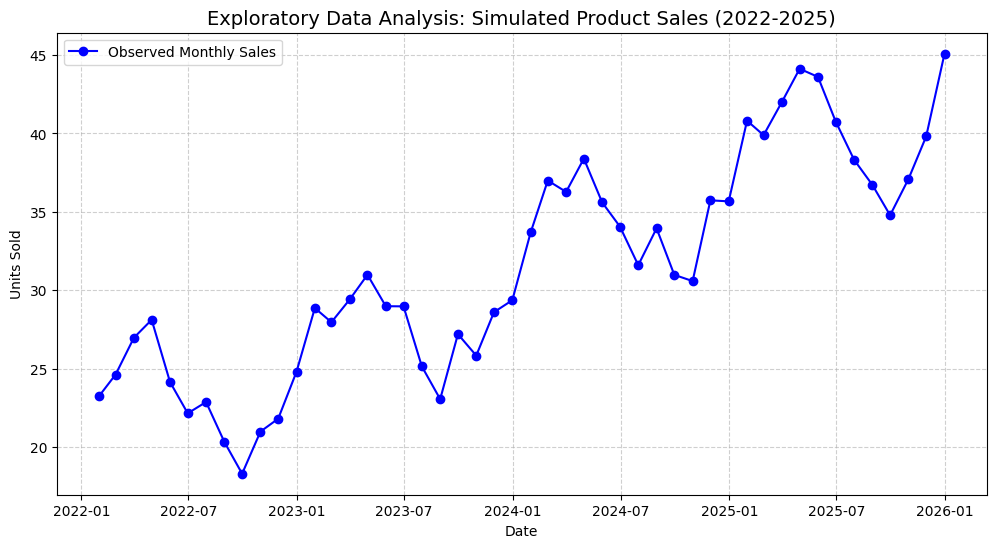

In [3]:
plt.figure(figsize=(12,6))

plt.plot(
    df.index,
    df['Sales'],
    marker='o',
    color='blue',
    label='Observed Monthly Sales'
)

plt.title(
    'Exploratory Data Analysis: Simulated Product Sales (2022-2025)',
    fontsize=14
)

plt.xlabel('Date')
plt.ylabel('Units Sold')

plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.show()

### **Split Data into Training and Testing Sets**

In [6]:
# First 36 months
train_df = df.iloc[:-12]

# Last 12 months
test_df = df.iloc[-12:]

print("Training Data Shape:", train_df.shape)
print("Testing Data Shape:", test_df.shape)

Training Data Shape: (36, 1)
Testing Data Shape: (12, 1)


### **Train Holt-Winters Exponential Smoothing Model**

In [7]:
model = ExponentialSmoothing(
    train_df['Sales'],
    trend='add',
    seasonal='add',
    seasonal_periods=12
).fit()

print(model.summary())

                       ExponentialSmoothing Model Results                       
Dep. Variable:                    Sales   No. Observations:                   36
Model:             ExponentialSmoothing   SSE                             52.379
Optimized:                         True   AIC                             45.499
Trend:                         Additive   BIC                             70.836
Seasonal:                      Additive   AICC                            85.735
Seasonal Periods:                    12   Date:                 Sat, 20 Jun 2026
Box-Cox:                          False   Time:                         04:58:52
Box-Cox Coeff.:                    None                                         
                          coeff                 code              optimized      
---------------------------------------------------------------------------------
smoothing_level               0.1694361                alpha                 True
smoothing_trend          

### **Generate Forecasts**

In [8]:
horizon = 12

forecast_idx = pd.date_range(
    start='2025-01-01',
    periods=horizon,
    freq='ME'
)

point_forecast = model.forecast(horizon)

point_forecast

,0
2025-01-31,40.513397
2025-02-28,41.889088
2025-03-31,43.022066
2025-04-30,44.735430
2025-05-31,41.908177
2025-06-30,40.815014
2025-07-31,39.038208
2025-08-31,38.353625
2025-09-30,38.142003
2025-10-31,38.514658


### **Calculate Prediction Intervals**

In [9]:
# Standard deviation of residuals
residual_std = np.std(model.resid)

# 95% Prediction Interval
lower_bound = point_forecast - 1.96 * residual_std
upper_bound = point_forecast + 1.96 * residual_std

print("Prediction Intervals Calculated Successfully")

Prediction Intervals Calculated Successfully


### **Visualize Forecast Results**

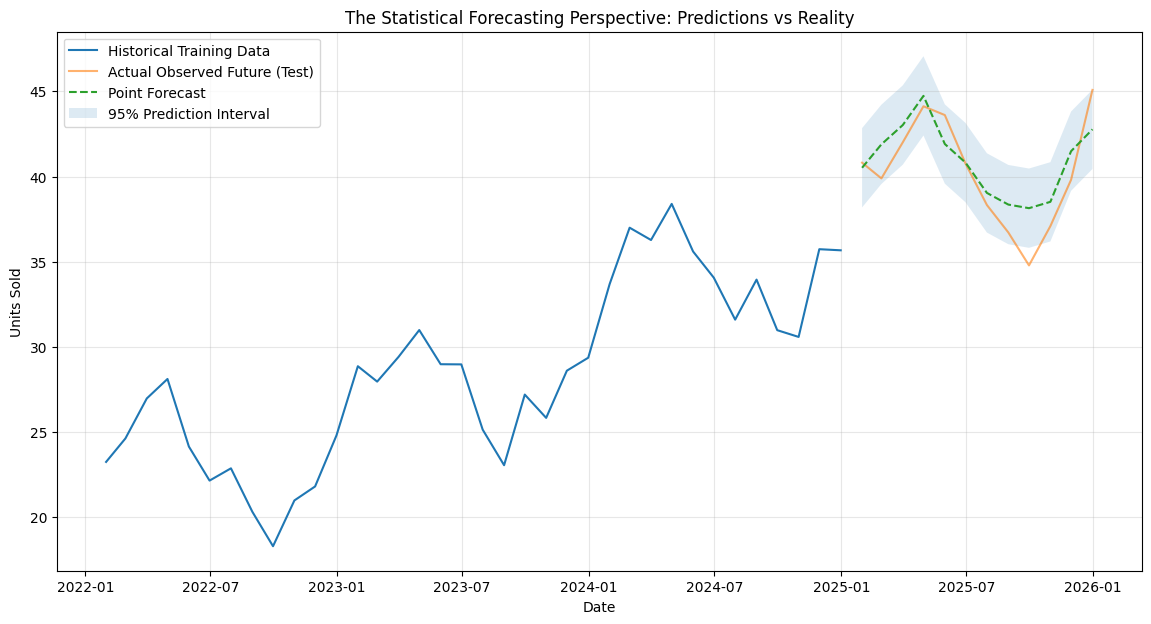

In [10]:
plt.figure(figsize=(14,7))

plt.plot(
    train_df.index,
    train_df['Sales'],
    label='Historical Training Data'
)

plt.plot(
    test_df.index,
    test_df['Sales'],
    label='Actual Observed Future (Test)',
    alpha=0.6
)

plt.plot(
    forecast_idx,
    point_forecast,
    linestyle='--',
    label='Point Forecast'
)

plt.fill_between(
    forecast_idx,
    lower_bound,
    upper_bound,
    alpha=0.15,
    label='95% Prediction Interval'
)

plt.title(
    'The Statistical Forecasting Perspective: Predictions vs Reality'
)

plt.xlabel('Date')
plt.ylabel('Units Sold')

plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)

plt.show()